# Mapping the Potential Destructive Power of Wildfires Using Machine Learning
---
## Module 7: *Modeling and Tuning*
##### Version Number: 3.0
---
### Contents  
> 1. *Random Forest*
> 2. *KNN Classifier*
> 3. *Neural Network*
> 3. *XGBoost*
> 5. *Export Optimum Configurations*
---
### Notes
This module **automatically** finds the optimal configuration of models based on the average F1 score of all three categories.

**WARNING** this module is very computation heavy
- Start with a **baseline model** for comparison.
- Test with multi-classification **tree-based models** (Random Forest, XGBoost) and Neural Networks.
- Use kfold **cross-validation** to tune hyperparameters for each model.
- Export optimal models

---
### Inputs
- `X.csv`- cleaned and scaled main weather dataset
- `y.csv`- multiclass target (0,1,2)

---
### Outputs  

`model_parameters.csv` - optimal parameters for each of the three models

---
### User Created Dependencies

In [1]:
# Add the parent directory to the system path so "src" can be found
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))


from src.model_utils import test_values

from src.model_utils import apply_balancing

---

### Third Party Dependencies

In [2]:
# Core Python libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and modeling
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

# Resampling tools
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

# Style
sns.set(style='whitegrid')
plt.rcParams["figure.dpi"] = 100

---

### Load File

In [3]:
# Load processed feature and label data
#best_strategy = pd.read_csv('../data/processed/best_strategy.csv')
X = pd.read_csv('../data/processed/X.csv')
y = pd.read_csv('../data/processed/y.csv').squeeze()

In [4]:
best_strategy = pd.read_csv('../data/processed/best_strategy.csv')

In [5]:
best_strategy

,Model_Label,Best_Strategy
0,XGB,No_balance
1,RF,No_balance
2,NN,No_balance


---

## 1. Random Forest Classifier

This section evaluates Hypertuning and class-balancing options for SciKitLearns **RandomForestClassifier**. Options are tested utilizing kfold validation. 
- `n_estimators` [50, 100, 150]
- `max_depth` [5, 10, 15, 20]
- `min_samples_split_values` = [2, 5, 10, 20, 50]
- `max_features` ['sqrt', 'log2']

In [6]:
X_train,y_train = apply_balancing('RF', best_strategy, X, y)

### 1.1 Hyperparameter Tuning

#### Number of Estimators (n_estimators)

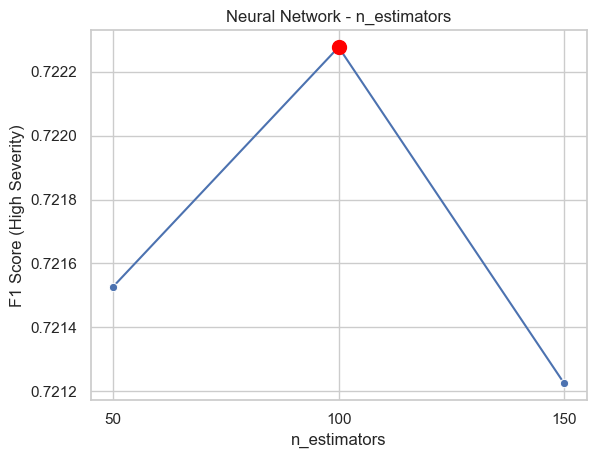

In [7]:
# Define parameter grid
estimators = [50, 100, 150]
optimum_n_estimator = test_values('RF','n_estimators',estimators,X_train, y_train)

optimum_n_estimator

#### Maximum Tree Depth (max_depth)

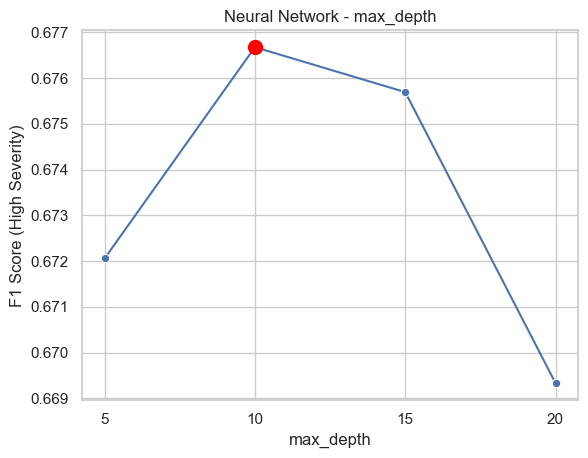

In [8]:
# Define parameter grid
max_depth = [5, 10, 15, 20] 
optimum_max_depth = test_values('RF','max_depth',max_depth,X_train, y_train)

In [9]:
optimum_max_depth

10

#### Maximum Features (max_features)

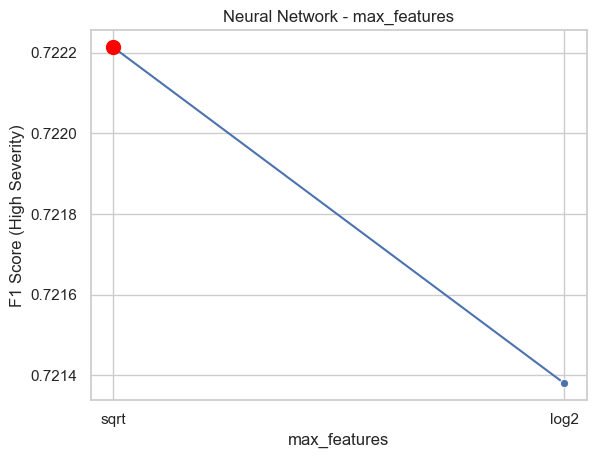

In [10]:
# Define parameter grid
max_features = ['sqrt', 'log2']
optimum_max_features = test_values('RF','max_features',max_features,X_train, y_train)

In [11]:
optimum_max_features

'sqrt'

#### Minimum Sample Split  (min_samples)

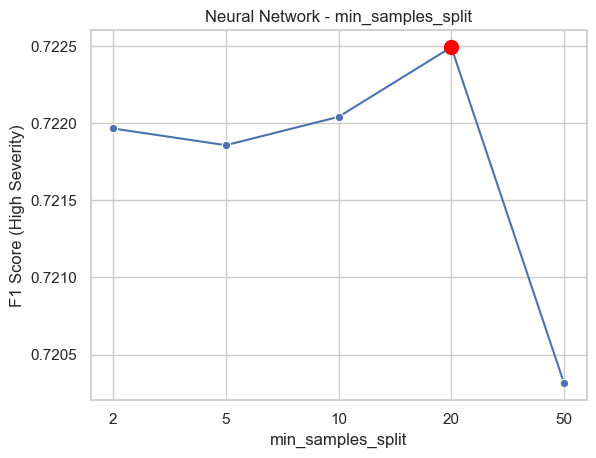

In [12]:
# Define parameter grid
min_samples_split_values = [2, 5, 10, 20, 50] 
optimum_min_samples_split = test_values('RF','min_samples_split',min_samples_split_values,X_train, y_train)

### 1.2 Final Random Forest Model

In [13]:
RF_parameters = {
    'n_estimators': optimum_n_estimator,
    'max_depth': optimum_max_depth,
    'min_samples_split': optimum_min_samples_split,
    'max_features': optimum_max_features,
    'class_weight':'balanced'
}

optimum_rf = RandomForestClassifier(**RF_parameters)

# Create DataFrame and format display
pd.DataFrame([RF_parameters]).style \
    .hide(axis='index') \
    .set_caption("Optimum Random Forest Parameters")

n_estimators,max_depth,min_samples_split,max_features,class_weight
100,10,20,sqrt,balanced


---

## 2. Neural Network

In [14]:
X_train,y_train = apply_balancing('NN', best_strategy, X, y)

### Hidden Layer Tuning

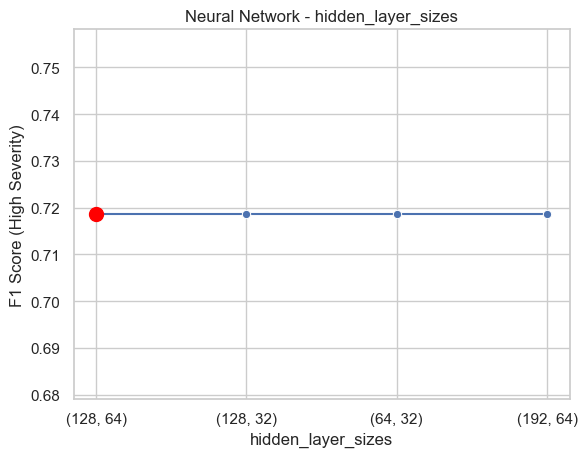

In [15]:
hidden_layers = [(128, 64), (128, 32),
    (64, 32), (192, 64)]

optimum_layer = test_values('NN','hidden_layer_sizes', hidden_layers, X_train, y_train)

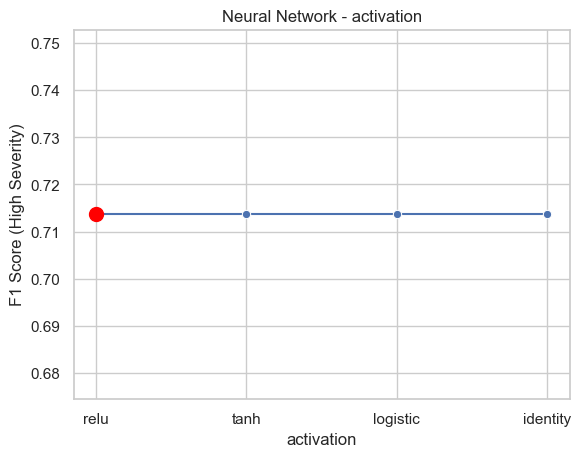

In [16]:
# Define parameter grid
activation_functions = ['relu', 'tanh', 'logistic', 'identity']
optimum_activation = test_values('NN','activation', activation_functions, X_train, y_train)

### Learning Rate Tuning

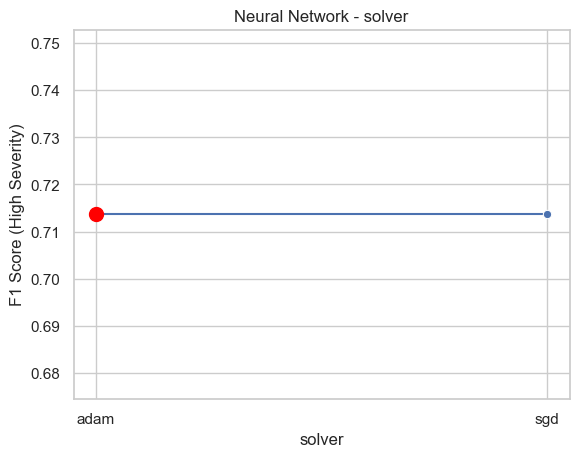

In [17]:
solvers =  ['adam', 'sgd']
optimum_solver = test_values('NN','solver', solvers, X_train, y_train)

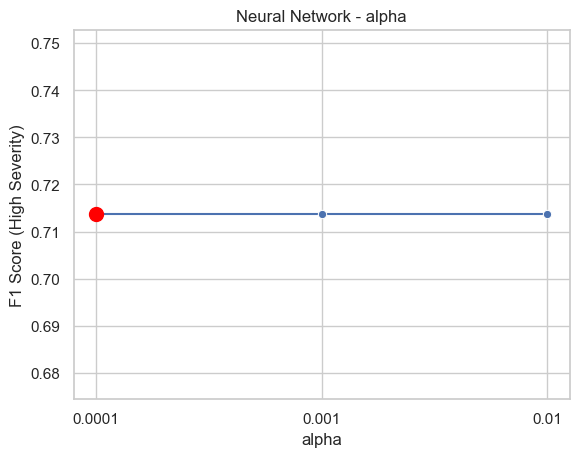

In [18]:
alphas = [0.0001, 0.001, 0.01]
optimum_alpha = test_values('NN','alpha', alphas, X_train, y_train)

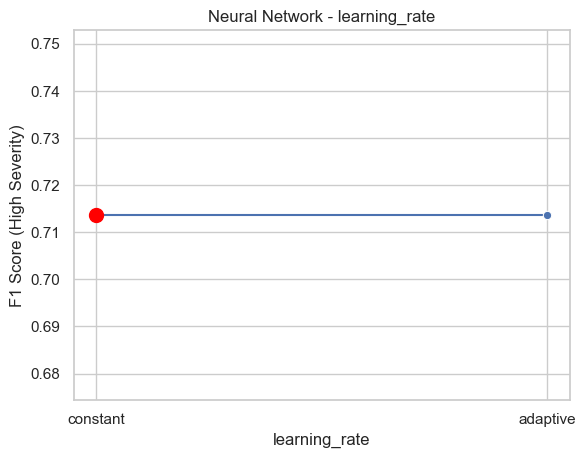

In [19]:
learning_rates = ['constant', 'adaptive']
optimum_learning_rate = test_values('NN','learning_rate', learning_rates, X_train, y_train)

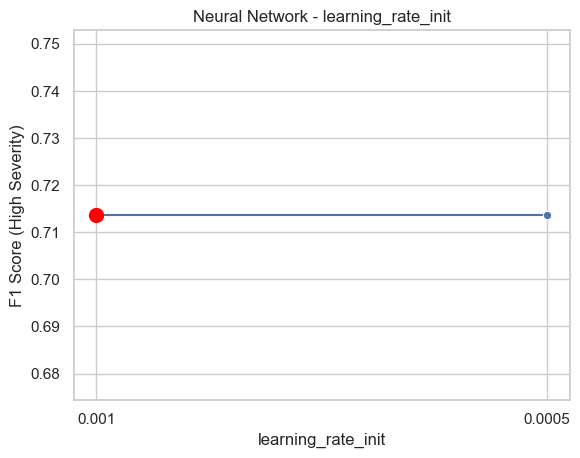

In [20]:
learning_rate_init = [0.001, 0.0005]
optimum_learning_rate_init = test_values('NN','learning_rate_init', learning_rate_init, X_train, y_train)

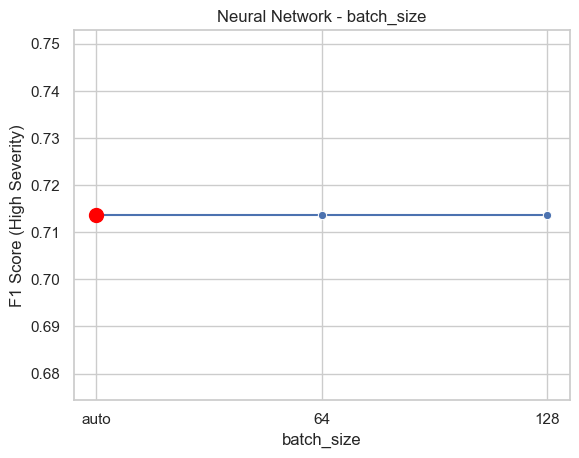

In [21]:
batch_sizes = ['auto', 64, 128]
optimum_batch_size = test_values('NN','batch_size', batch_sizes, X_train, y_train)

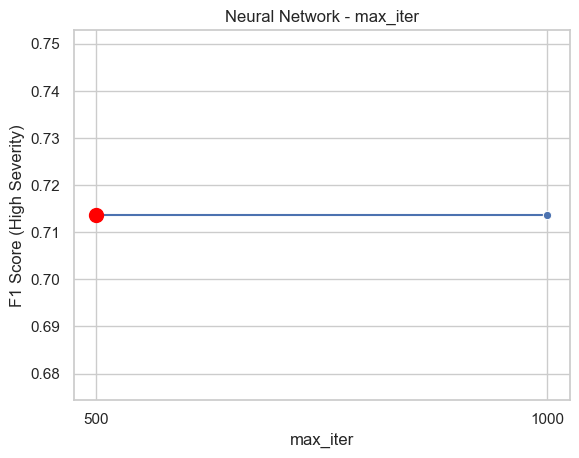

In [22]:
max_iter = [500, 1000]
optimum_max_iter = test_values('NN','max_iter', max_iter, X_train, y_train)

In [23]:
nn_params = {
    'hidden_layer_sizes': optimum_layer, 
    'activation': optimum_activation, 
    'solver': optimum_solver, 
    'alpha': optimum_alpha,                 
    'batch_size': optimum_batch_size,
    'learning_rate': optimum_learning_rate,
    'learning_rate_init': optimum_learning_rate_init,
    'max_iter': optimum_max_iter, 
    'early_stopping': True, 
    'random_state': 14,
    'verbose': False
}
        

optimum_nn = MLPClassifier(**nn_params)

# Create DataFrame and format display
pd.DataFrame([nn_params]).style \
    .hide(axis='index') \
    .set_caption("Optimum Neural Network Parameters")

hidden_layer_sizes,activation,solver,alpha,batch_size,learning_rate,learning_rate_init,max_iter,early_stopping,random_state,verbose
"(128, 64)",relu,adam,0.000100,auto,constant,0.001000,500,True,14,False


---

## 3. XGBoost Classifier

This section trains an XGBoost classifier using grid-based hyperparameter tuning and evaluates performance under different sampling strategies.

In [24]:
X_train,y_train = apply_balancing('XGB', best_strategy, X, y)

### 3.2 Hyperparameter Tuning

#### n_estimators Tuning

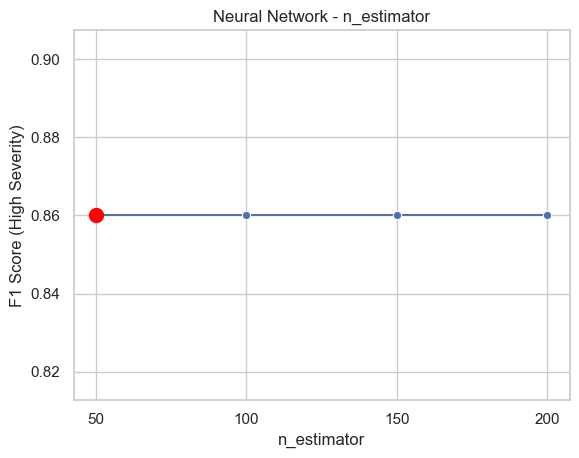

In [25]:
n_estimators = [50, 100, 150, 200]
optimum_n_estimator = test_values('XGB','n_estimator', n_estimators, X_train, y_train)

#### learning_rate Tuning

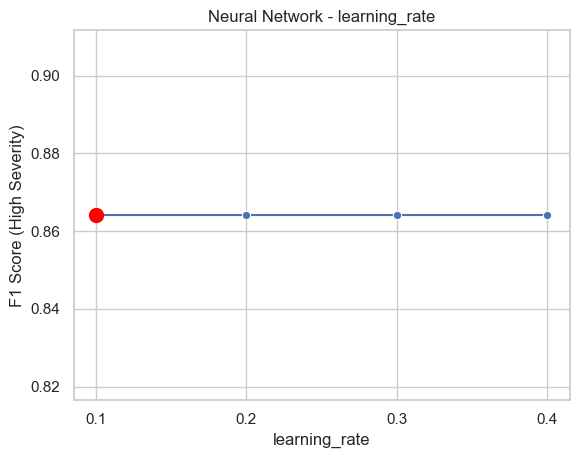

In [26]:
learning_rates = [0.1, 0.2, 0.3, 0.4]
optimum_learning_rate = test_values('XGB','learning_rate', learning_rates, X_train, y_train)

#### max_depth Tuning

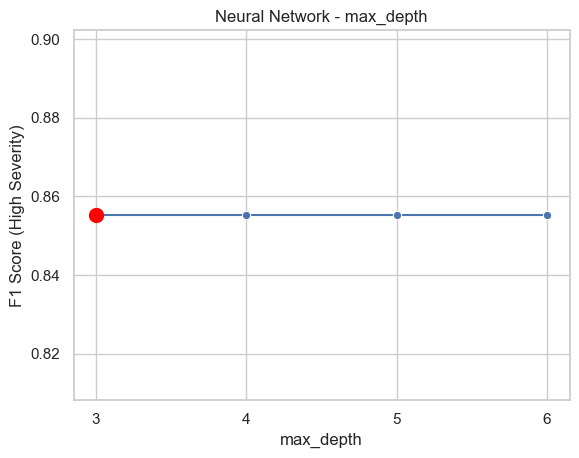

In [27]:
max_depths = [3, 4, 5, 6]
optimum_max_depth = test_values('XGB','max_depth', max_depths, X_train, y_train)

### 3.3 Final XGBoost Model

In [28]:
XGB_parameters = {
    'objective': 'multi:softmax',
    'num_class': 3,
    'n_estimators': optimum_n_estimator,
    'max_depth': optimum_max_depth,
    'learning_rate': optimum_learning_rate,
}


optimum_xgb_model = xgb.XGBClassifier(
    **XGB_parameters
)

# Create DataFrame and format display
pd.DataFrame([XGB_parameters]).style \
    .hide(axis='index') \
    .set_caption("Optimum XGBoost Parameters")

objective,num_class,n_estimators,max_depth,learning_rate
multi:softmax,3,50,3,0.100000


---

## 4. Export Data

In [29]:
model_params = {
    'RandomForest': RF_parameters,
    'XGBoost': XGB_parameters,
    'NN': nn_params
}
# Flatten the dict into a DataFrame
model_parameters = pd.DataFrame.from_dict(model_params, orient='index')


In [30]:
# Save to CSV
model_parameters.to_csv('../data/processed/model_parameters.csv')
print("All datasets saved successfully to ../data/processed/")

All datasets saved successfully to ../data/processed/
